# 1. 데이터 불러오기

In [50]:
import yfinance as yf
from datetime import date, timedelta

year = 5
today = date.today()
end_date = today.strftime("%Y-%m-%d")
start_date = today - timedelta(days=365*year)

print(start_date, end_date)

data = yf.download(
    tickers = "009450.KS",
    start = start_date,
    end = end_date
)

data.head()

C:\Users\user\AppData\Local\Temp\ipykernel_58972\329256494.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed

2020-09-10 2025-09-09


Price,Close,High,Low,Open,Volume
Ticker,009450.KS,009450.KS,009450.KS,009450.KS,009450.KS
Date,,,,,
2020-09-10,57102.957031,58816.045742,55009.181940,55389.868320,384979
2020-09-11,57293.300781,58054.673549,55389.868862,56531.928013,153445
2020-09-14,55865.730469,57293.304501,55580.215662,57293.304501,125104
2020-09-15,56246.414062,56531.928855,54438.153712,55865.727673,107441
2020-09-16,55865.730469,58530.535329,54533.328038,56246.416877,234832


In [51]:
# 멀티컬럼 제거
data.columns = data.columns.droplevel(1)
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-09-10,57102.957031,58816.045742,55009.181940,55389.868320,384979
2020-09-11,57293.300781,58054.673549,55389.868862,56531.928013,153445
2020-09-14,55865.730469,57293.304501,55580.215662,57293.304501,125104
2020-09-15,56246.414062,56531.928855,54438.153712,55865.727673,107441
2020-09-16,55865.730469,58530.535329,54533.328038,56246.416877,234832


In [52]:
data = data[["Close"]]
data.head()

Price,Close
Date,
2020-09-10,57102.957031
2020-09-11,57293.300781
2020-09-14,55865.730469
2020-09-15,56246.414062
2020-09-16,55865.730469


```
uv add scikit-learn
uv add pandas matplotlib
uv pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
```

In [53]:
# CUDA를 사용하기 위한 torch 설치
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# 2. 데이터 분할

In [54]:
N = len(data)
test_ratio = 0.2
val_ratio = 0.1

test_size = int(N * test_ratio)
val_size = int(N * val_ratio)
train_size = N - val_size - test_size

train_data = data.iloc[:train_size]
val_data = data.iloc[train_size : (train_size+val_size)]
test_data = data.iloc[(train_size + val_size):]

print(f"Train Data : {train_data.shape}, Val Data : {val_data.shape}, Test Data : {test_data.shape}")

Train Data : (857, 1), Val Data : (122, 1), Test Data : (244, 1)


# 3. 데이터 스케일러 적용

In [55]:
from sklearn.preprocessing import MinMaxScaler
# Q1. MinMaxScaler ?
# Q2. 스케일러를 사용할 때 반드시 주의해야 할 점?
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data.values)
val_scaled = scaler.transform(val_data.values)
test_scaled = scaler.transform(test_data.values)

print(f"train_scaled : {train_scaled.dtype}")
print(f"val_scaled : {val_scaled.dtype}")
print(f"test_scaled : {test_scaled.dtype}")

print(f"Scale 범위 : {scaler.data_min_}, {scaler.data_max_}")

train_scaled : float64
val_scaled : float64
test_scaled : float64
Scale 범위 : [32080.44335938], [74072.03125]


# 4. 학습 데이터 생성

In [56]:
train_scaled.shape

(857, 1)

In [57]:
# 데이터 움직이는 패턴 파악
window = 7
for i in range(0, 14 - window):
    print(i, i+window)

0 7
1 8
2 9
3 10
4 11
5 12
6 13


In [58]:
import numpy as np
# Q1. Window가 무엇을 의미하는지 설명
# Q2. train data가 몇 개 나오는지 설명
def make_dataset(data, window):
    dataX = []
    datay = []

    for i in range(0, data.shape[0] - window):
        x = data[i:(i+window), :]
        y = data[(i+window), [-1]]

        dataX.append(x)
        datay.append(y)
    
    return np.array(dataX), np.array(datay)

window = 60
X_train, y_train = make_dataset(train_scaled, window=window)
# val_scaled 의 X,y를 만들기 위해서는 train_scaled에서 맨 뒤에서 window만큼 가져와야 한다
X_val, y_val = make_dataset(np.concatenate([train_scaled[-window:], val_scaled]), window=60)
X_test, y_test = make_dataset(np.concatenate([val_scaled[-window:], test_scaled]), window=60)
print(train_scaled.shape, X_train.shape, y_train.shape)
print(val_scaled.shape, X_val.shape, y_val.shape)
print(test_scaled.shape, X_test.shape, y_test.shape)

(857, 1) (797, 60, 1) (797, 1)
(122, 1) (122, 60, 1) (122, 1)
(244, 1) (244, 60, 1) (244, 1)


# 5. DataLoader 만들기

In [59]:
import torch

# numpy 배열을 tensor로 바꾸기

X_train_ts = torch.FloatTensor(X_train)
y_train_ts = torch.FloatTensor(y_train)
X_val_ts = torch.FloatTensor(X_val)
y_val_ts = torch.FloatTensor(y_val)
X_test_ts = torch.FloatTensor(X_test)
y_test_ts = torch.FloatTensor(y_test)

In [60]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_ts, y_train_ts)
print(len(train_dataset))
# print(train_dataset[0])

val_dataset = TensorDataset(X_test_ts, y_test_ts)
print(len(val_dataset))
# print(val_dataset[0])

test_dataset = TensorDataset(X_test_ts, y_test_ts)
print(len(test_dataset))
# print(test_dataset[0])

797
244
244


In [61]:
batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

# 6. 모델 만들기

In [62]:
import torch.nn as nn

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout= dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # out : 모든 시점의 요약
        # hn : 마지막 시점의 Hidden State
        # cn : 마지막 시점의 Cell State
        out, (hn, cn) = self.lstm(x)
        pred = self.fc(hn[-1])

        return pred

In [63]:
# 모델 만들기
model = LSTMRegressor(
    input_size=1,
    hidden_size=128,
    num_layers=2,
    dropout=0.2
)
model

LSTMRegressor(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [64]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

LSTMRegressor(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

# 7. 학습하기

In [65]:
# 정의
lr = 1e-5
criterion = nn.MSELoss()    # 손실함수
optimizer = torch.optim.Adam(model.parameters(), lr=lr) # 최적화 함수
epochs = 100     # epoch

In [66]:
# 학습
best_val_loss = float("inf")
patience = 0
loss_history = []
for epoch in range(epochs):
    # Train
    model.train()

    train_loss_history = []
    for data, target in train_dataloader:
        # 데이터 GPU 보내기
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()   # 초기화
        pred = model(data)      # 예측
        loss = criterion(pred, target)  # 손실 계산
        loss.backward()         # 역전파
        optimizer.step()        # 최적화함수 업데이트

        # 손실 저장
        train_loss_history.append(loss.item())

    # Validation
    model.eval()

    val_loss_history = []
    with torch.no_grad():
        for data, target in val_dataloader:
            data = data.to(device)
            target = target.to(device)

            pred = model(data)
            loss = criterion(pred, target)
            val_loss_history.append(loss.item())
    
    # 출력
    train_loss = float(np.mean(train_loss_history))
    val_loss = float(np.mean(val_loss_history))

    loss_history.append(train_loss)
    print(f"Epoch: {epoch}, train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

    # 학습 끝내는 조건
    if val_loss < best_val_loss:
        best_val_loss = val_loss 
        patience = 0
        torch.save(model.state_dict(), "best.pth")
    else:
        patience += 1
        if patience >= 10:
            break

# 학습 저장
torch.save(model.state_dict(), "last.pt")

Epoch: 0, train_loss=0.1535, val_loss=1.2212
Epoch: 1, train_loss=0.1489, val_loss=1.2047
Epoch: 2, train_loss=0.1445, val_loss=1.1882
Epoch: 3, train_loss=0.1401, val_loss=1.1717
Epoch: 4, train_loss=0.1360, val_loss=1.1551
Epoch: 5, train_loss=0.1317, val_loss=1.1385
Epoch: 6, train_loss=0.1276, val_loss=1.1216
Epoch: 7, train_loss=0.1235, val_loss=1.1045
Epoch: 8, train_loss=0.1193, val_loss=1.0870
Epoch: 9, train_loss=0.1153, val_loss=1.0691
Epoch: 10, train_loss=0.1112, val_loss=1.0507
Epoch: 11, train_loss=0.1071, val_loss=1.0317
Epoch: 12, train_loss=0.1031, val_loss=1.0122
Epoch: 13, train_loss=0.0990, val_loss=0.9920
Epoch: 14, train_loss=0.0950, val_loss=0.9710
Epoch: 15, train_loss=0.0910, val_loss=0.9494
Epoch: 16, train_loss=0.0870, val_loss=0.9271
Epoch: 17, train_loss=0.0833, val_loss=0.9041
Epoch: 18, train_loss=0.0797, val_loss=0.8805
Epoch: 19, train_loss=0.0760, val_loss=0.8563
Epoch: 20, train_loss=0.0725, val_loss=0.8318
Epoch: 21, train_loss=0.0693, val_loss=0.807

# 8. 시각화

Text(0, 0.5, 'loss')

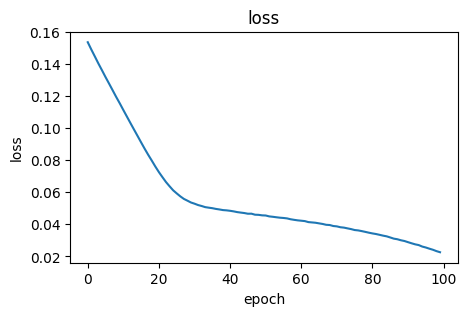

In [67]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(5,3))
plt.plot(loss_history)
plt.title("loss")
plt.xlabel("epoch")
plt.ylabel("loss")

# 9. 예측하기

In [68]:
# Validation 
model.eval()

test_loss_history = []
with torch.no_grad():
    for data, target in test_dataloader:
        data = data.to(device)
        target = target.to(device)

        pred = model(data)
        loss = criterion(pred, target)
        test_loss_history.append(loss.item())

print(float(np.mean(test_loss_history)))

0.07375481608323753


# 10. 예측 시각화

In [69]:
X_test_ts = torch.FloatTensor(X_test)
y_test_ts = torch.FloatTensor(y_test)

# 예측값 저장
pred_history = []
for i in range(len(X_test_ts)):
    with torch.no_grad():
        data = X_test_ts[i].to(device)
        pred = model(data.unsqueeze(dim=0))
        print(pred.item())
        pred_history.append(pred.item())

0.644294261932373
0.6472365856170654
0.6474888324737549
0.6465773582458496
0.64524245262146
0.6439396142959595
0.6432006359100342
0.6431032419204712
0.644001841545105
0.6457679271697998
0.6482627391815186
0.6517688035964966
0.6556116342544556
0.6588773727416992
0.6625146865844727
0.6670039892196655
0.6714622974395752
0.6760387420654297
0.6803739070892334
0.6842048168182373
0.6876599788665771
0.6930255889892578
0.7009536027908325
0.7108687162399292
0.7243103981018066
0.7414841651916504
0.7620398998260498
0.7841864824295044
0.8071781396865845
0.8297488689422607
0.8535746335983276
0.8774160146713257
0.9006767272949219
0.9217548370361328
0.940518856048584
0.9565058946609497
0.9709174633026123
0.9838463068008423
0.9955826997756958
1.0055413246154785
1.0152260065078735
1.024351954460144
1.032014012336731
1.0391957759857178
1.047940969467163
1.0560373067855835
1.0648667812347412
1.0739598274230957
1.0807830095291138
1.0846011638641357
1.0866445302963257
1.0861581563949585
1.0825722217559814
1

In [70]:
# Scaler 되돌리기 
pred_inverse = scaler.inverse_transform(np.array(pred_history).reshape(-1,1))
# print(np.array(pred_history))
# print(np.array(pred_history).reshape(-1,1))
# print(pred_inverse)

y_test_inverse = scaler.inverse_transform(y_test_ts)

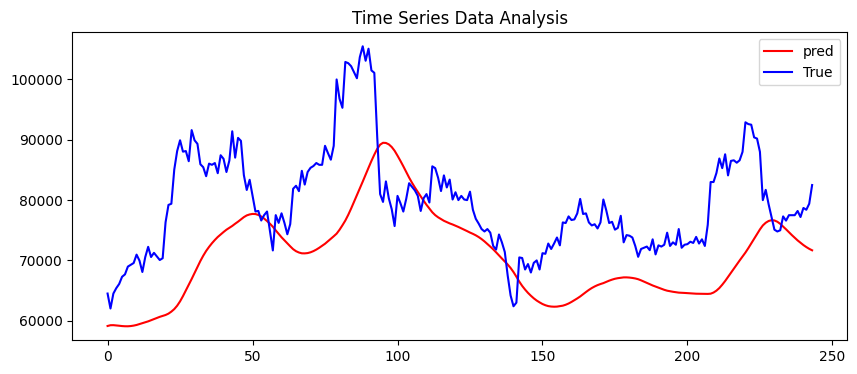

In [71]:
plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(pred_inverse)), pred_inverse, label="pred", color="r")
plt.plot(np.arange(len(y_test_inverse)), y_test_inverse, label="True", color="b")
plt.legend()
plt.title("Time Series Data Analysis")
plt.show()